In [13]:
import zipfile, os

zip_path = '/content/Financial Phrase Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/financial_data')

for root, dirs, files in os.walk('/content/financial_data'):
    for f in files:
        print(os.path.join(root, f))

/content/financial_data/3. Financial Phrase Dataset/3. Description Financial Phrase Dataset.txt
/content/financial_data/3. Financial Phrase Dataset/financial_phrase.csv


In [14]:
!pip install nltk --quiet
!pip install wordcloud --quiet

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [15]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

df = pd.read_csv('/content/financial_data/3. Financial Phrase Dataset/financial_phrase.csv',
                 encoding='latin-1')

print("Shape before cleaning:", df.shape)
print(df['label'].value_counts())

Shape before cleaning: (2264, 2)
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


In [16]:
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['cleaned'] = df['text'].apply(clean_text)

print("\nSample original:", df['text'].iloc[0])
print("Sample cleaned: ", df['cleaned'].iloc[0])

Shape after removing duplicates: (2259, 2)

Sample original: According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
Sample cleaned:  according gran company plan move production russia although company growing


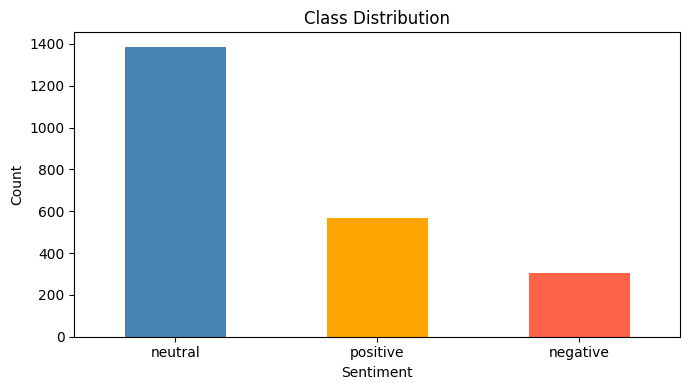

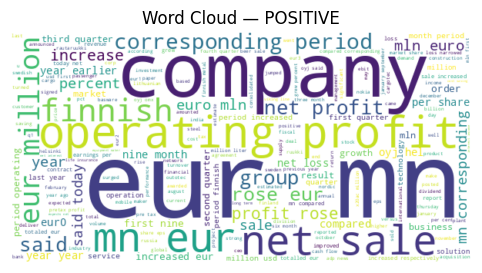

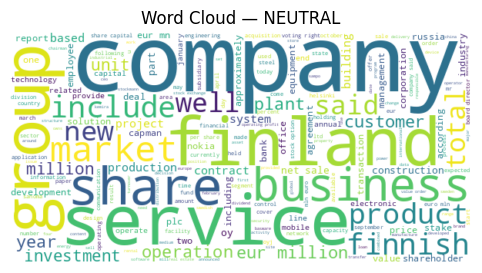

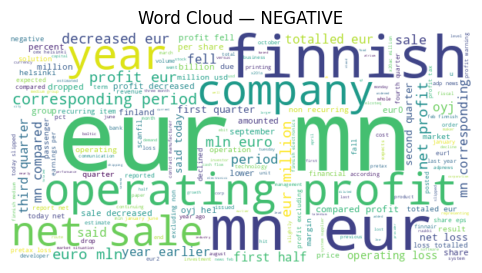

In [17]:
plt.figure(figsize=(7,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue','orange','tomato'])
plt.title('Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

for label in ['positive', 'neutral', 'negative']:
    text = ' '.join(df[df['label']==label]['cleaned'])
    wc = WordCloud(width=600, height=300, background_color='white').generate(text)
    plt.figure(figsize=(8,3))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud — {label.upper()}')
    plt.show()

In [18]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])
y_cat = to_categorical(y_encoded, num_classes=3)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df['cleaned'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_cat, test_size=0.15, random_state=42, stratify=y_encoded)

y_temp_labels = le.transform(df.loc[df['cleaned'].isin(X_temp), 'label'])

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

MAX_WORDS = 5000
MAX_LEN   = 50

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN, padding='post')
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post')

print("X_train shape:", X_train_pad.shape)

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Train: 1582 | Val: 338 | Test: 339
X_train shape: (1582, 50)


In [19]:
from sklearn.utils.class_weight import compute_class_weight

y_train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(2.4874213836477987), 1: np.float64(0.5386448757235274), 2: np.float64(1.3486786018755328)}


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

VOCAB_SIZE  = MAX_WORDS
EMBED_DIM   = 64
NUM_CLASSES = 3

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='SimpleRNN')

rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM')

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
!pip install --upgrade gensim --quiet

In [22]:
import gensim
print(gensim.__version__)

4.4.0


In [23]:
import gensim.downloader as api
print("Downloading GloVe... this takes 1-2 mins")
glove_model = api.load('glove-wiki-gigaword-50')
print("Done!")

Done!


In [24]:
import gensim.downloader as api
import numpy as np

print("Downloading GloVe embeddings... (this takes 1-2 mins)")
glove_model = api.load('glove-wiki-gigaword-50')

word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, 50))

for word, i in word_index.items():
    if i < VOCAB_SIZE and word in glove_model:
        embedding_matrix[i] = glove_model[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")

lstm_glove = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=50,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_GloVe')

lstm_glove.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_glove.summary()

Embedding matrix shape: (5000, 50)


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,000 (976.56 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 250,000 (976.56 KB)

In [25]:
print("Training Model 1: Simple RNN...")
hist_rnn = rnn_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[es], verbose=1
)

print("Training Model 2: LSTM...")
hist_lstm = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[es], verbose=1
)

print("Training Model 3: LSTM + GloVe...")
hist_glove = lstm_glove.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[es], verbose=1
)

Training Model 1: Simple RNN...
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.4387 - loss: 1.0908 - val_accuracy: 0.4083 - val_loss: 1.0714
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6207 - loss: 0.9233 - val_accuracy: 0.4349 - val_loss: 1.1127
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6941 - loss: 0.7825 - val_accuracy: 0.5917 - val_loss: 0.9249
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8489 - loss: 0.4941 - val_accuracy: 0.6065 - val_loss: 0.9483
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8989 - loss: 0.3474 - val_accuracy: 0.5858 - val_loss: 1.0941
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9330 - loss: 0.2224 - val_accuracy: 0.4882 - val_loss: 1.5703
Training Model 2: LSTM...
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.3344 - loss: 1.1010 - val_accuracy: 0.5888 - val_loss: 1.0888
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - a

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step

  Simple RNN
              precision    recall  f1-score   support

    negative       0.28      0.29      0.29        45
     neutral       0.91      0.74      0.81       208
    positive       0.42      0.60      0.50        86

    accuracy                           0.64       339
   macro avg       0.54      0.54      0.53       339
weighted avg       0.70      0.64      0.66       339



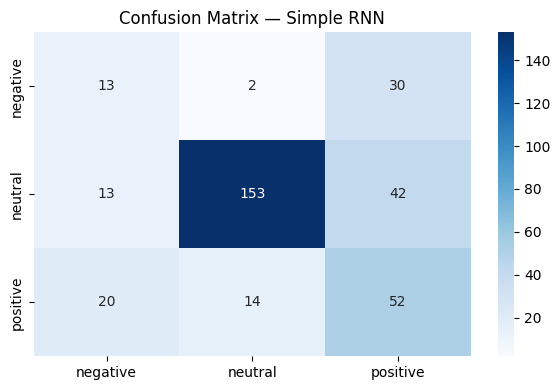

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

  LSTM
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        45
     neutral       0.61      1.00      0.76       208
    positive       0.00      0.00      0.00        86

    accuracy                           0.61       339
   macro avg       0.20      0.33      0.25       339
weighted avg       0.38      0.61      0.47       339



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


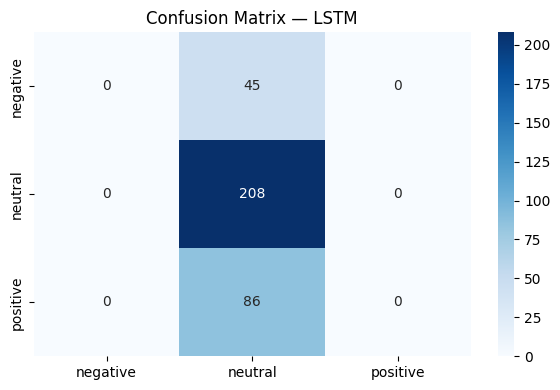

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

  LSTM + GloVe
              precision    recall  f1-score   support

    negative       0.38      0.91      0.54        45
     neutral       0.91      0.88      0.90       208
    positive       0.37      0.13      0.19        86

    accuracy                           0.70       339
   macro avg       0.55      0.64      0.54       339
weighted avg       0.70      0.70      0.67       339



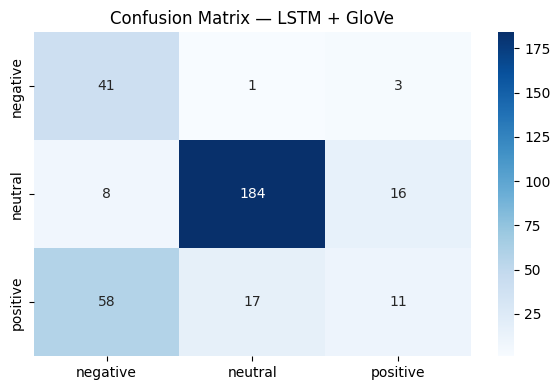

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, X_test, y_test, name, le):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix — {name}')
    plt.tight_layout(); plt.show()

evaluate_model(rnn_model,  X_test_pad, y_test, 'Simple RNN', le)
evaluate_model(lstm_model, X_test_pad, y_test, 'LSTM', le)
evaluate_model(lstm_glove, X_test_pad, y_test, 'LSTM + GloVe', le)

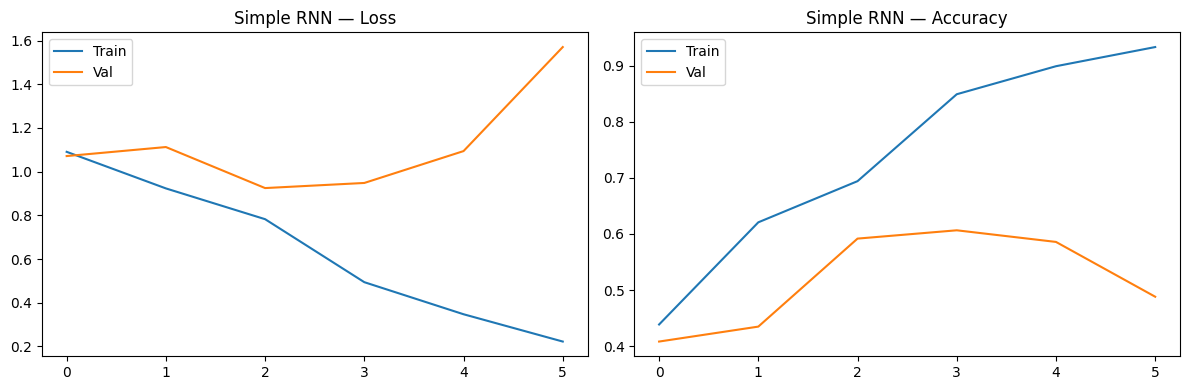

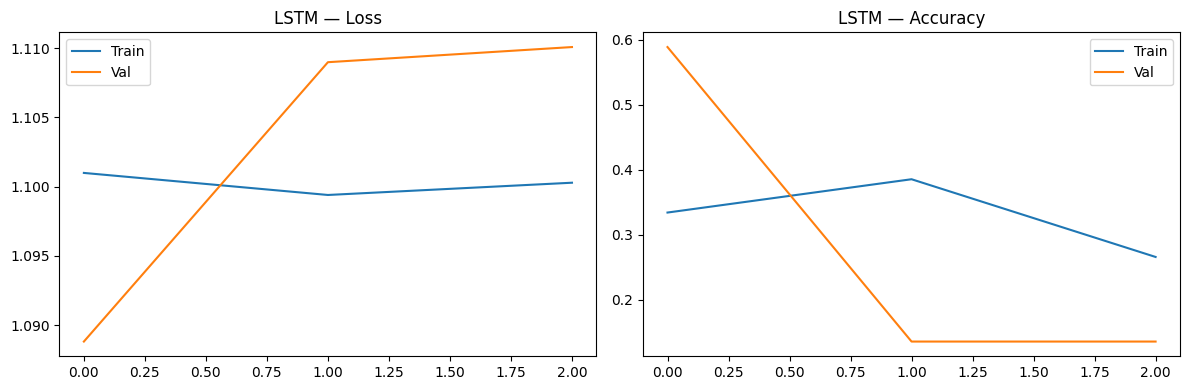

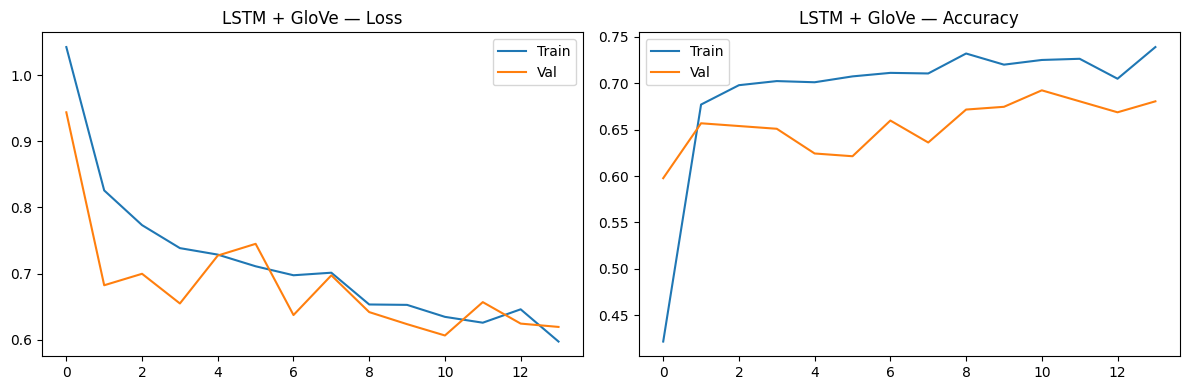

In [27]:
def plot_history(hist, name):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title(f'{name} — Loss'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history['accuracy'], label='Train')
    plt.plot(hist.history['val_accuracy'], label='Val')
    plt.title(f'{name} — Accuracy'); plt.legend()
    plt.tight_layout(); plt.show()

plot_history(hist_rnn,   'Simple RNN')
plot_history(hist_lstm,  'LSTM')
plot_history(hist_glove, 'LSTM + GloVe')

In [28]:
y_pred_labels = np.argmax(lstm_glove.predict(X_test_pad), axis=1)
y_true_labels = np.argmax(y_test, axis=1)

misclassified = np.where(y_pred_labels != y_true_labels)[0]
print(f"Total misclassified: {len(misclassified)}\n")

for i in misclassified[:3]:
    print(f"Text:      {X_test[i]}")
    print(f"True:      {le.classes_[y_true_labels[i]]}")
    print(f"Predicted: {le.classes_[y_pred_labels[i]]}")
    print("-" * 60)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Total misclassified: 103

Text:      measure expected produce annual cost saving eur million starting 2007
True:      positive
Predicted: neutral
------------------------------------------------------------
Text:      pretax profit totalled eur mn compared loss eur 159 mn fourth quarter 2008
True:      positive
Predicted: negative
------------------------------------------------------------
Text:      financing arrangement enable company ensure line treasury policy sufficient financial instrument disposal potential capital requirement
True:      positive
Predicted: neutral
------------------------------------------------------------
